In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost", "optuna"])


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from catboost import CatBoostClassifier
import optuna

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
file_path = "data/combined.csv"
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   52    1                0         125.0        212.0                    0   
1   53    1                0         140.0        203.0                    1   
2   70    1                0         145.0        174.0                    0   
3   61    1                0         148.0        203.0                    0   
4   62    0                0         138.0        294.0                    1   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            1             168                0      1.0         2       0  
1            0             155                1      3.1         0       0  
2            1             125                1      2.6         0       0  
3            1             161                0      0.0         2       0  
4            1             106                0      1.9         1       0  

Shape of dataset:
(1220, 12)


In [4]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1220 non-null   int64  
 1   sex                  1220 non-null   int64  
 2   chest pain type      1220 non-null   int64  
 3   resting bp s         1219 non-null   float64
 4   cholesterol          1048 non-null   float64
 5   fasting blood sugar  1220 non-null   int64  
 6   resting ecg          1220 non-null   int64  
 7   max heart rate       1220 non-null   int64  
 8   exercise angina      1220 non-null   int64  
 9   oldpeak              1220 non-null   float64
 10  ST slope             1220 non-null   int64  
 11  target               1220 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 114.5 KB


age                      int64
sex                      int64
chest pain type          int64
resting bp s           float64
cholesterol            float64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

In [5]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                 0
target                   0
dtype: int64

In [6]:
df["target"].value_counts()

target
1    672
0    548
Name: count, dtype: int64

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

In [8]:
categorical_features = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]

cat_indices = [X.columns.get_loc(col) for col in categorical_features if col in X.columns]

# Cast categorical columns to int for CatBoost
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype(int)

print("Categorical feature indices:", cat_indices)

Categorical feature indices: [1, 2, 5, 6, 8, 10]


In [9]:
print("Data types:")
print(X.dtypes)

print("\nMissing values per column:")
print(X.isna().sum())

Data types:
age                      int64
sex                      int64
chest pain type          int64
resting bp s           float64
cholesterol            float64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
dtype: object

Missing values per column:
age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                 0
dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (976, 11)
X_test:  (244, 11)


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
def objective_catboost(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.1, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True)

    model = CatBoostClassifier(
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        random_state=42,
        verbose=0,
        iterations=1000,
        early_stopping_rounds=50,
        cat_features=cat_indices
    )
    model.fit(X_train, y_train, eval_set=(X_test, y_test))
    return accuracy_score(y_test, model.predict(X_test))

In [13]:
study = optuna.create_study(direction="maximize", study_name="CatBoost_Hyperparameter_Optimization")
study.optimize(objective_catboost, n_trials=50)

print(f"Best trial:")
print(f"  Accuracy: {study.best_value:.4f}")
print(f"  Params:   {study.best_params}")

[I 2026-03-22 14:38:16,184] A new study created in memory with name: CatBoost_Hyperparameter_Optimization


[I 2026-03-22 14:38:16,421] Trial 0 finished with value: 0.8319672131147541 and parameters: {'learning_rate': 0.08141536475762404, 'depth': 8, 'l2_leaf_reg': 0.10554855069968691}. Best is trial 0 with value: 0.8319672131147541.


[I 2026-03-22 14:38:16,713] Trial 1 finished with value: 0.8073770491803278 and parameters: {'learning_rate': 0.03217892276943305, 'depth': 8, 'l2_leaf_reg': 5.784775123988789}. Best is trial 0 with value: 0.8319672131147541.


[I 2026-03-22 14:38:16,865] Trial 2 finished with value: 0.7991803278688525 and parameters: {'learning_rate': 0.09116475279443498, 'depth': 8, 'l2_leaf_reg': 0.2750423487252496}. Best is trial 0 with value: 0.8319672131147541.


[I 2026-03-22 14:38:17,237] Trial 3 finished with value: 0.8278688524590164 and parameters: {'learning_rate': 0.021724529747410095, 'depth': 10, 'l2_leaf_reg': 0.3091756250618951}. Best is trial 0 with value: 0.8319672131147541.


...

[I 2026-03-22 14:38:36,518] Trial 46 finished with value: 0.7950819672131147 and parameters: {'learning_rate': 0.06314801905668753, 'depth': 6, 'l2_leaf_reg': 0.04494385656434448}. Best is trial 37 with value: 0.8401639344262295.


[I 2026-03-22 14:38:37,223] Trial 47 finished with value: 0.8114754098360656 and parameters: {'learning_rate': 0.002016384969014226, 'depth': 4, 'l2_leaf_reg': 0.14053680732813026}. Best is trial 37 with value: 0.8401639344262295.


[I 2026-03-22 14:38:37,884] Trial 48 finished with value: 0.8073770491803278 and parameters: {'learning_rate': 0.00969700789285484, 'depth': 10, 'l2_leaf_reg': 0.8821641984935877}. Best is trial 37 with value: 0.8401639344262295.


[I 2026-03-22 14:38:38,228] Trial 49 finished with value: 0.8155737704918032 and parameters: {'learning_rate': 0.022910453981468466, 'depth': 7, 'l2_leaf_reg': 3.292921026449675}. Best is trial 37 with value: 0.8401639344262295.


Best trial:
  Accuracy: 0.8402
  Params:   {'learning_rate': 0.088836232582905, 'depth': 8, 'l2_leaf_reg': 2.6581093825796738}


In [14]:
best = study.best_params

best_catboost_model = CatBoostClassifier(
    learning_rate=best["learning_rate"],
    depth=best["depth"],
    l2_leaf_reg=best["l2_leaf_reg"],
    random_state=42,
    verbose=0,
    iterations=1000,
    cat_features=cat_indices
)

print("Best CatBoost model:")
print(best_catboost_model.get_params())

Best CatBoost model:
{'iterations': 1000, 'learning_rate': 0.088836232582905, 'depth': 8, 'l2_leaf_reg': 2.6581093825796738, 'verbose': 0, 'random_state': 42, 'cat_features': [1, 2, 5, 6, 8, 10]}


In [15]:
from sklearn.metrics import precision_score

fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []

for tr_idx, va_idx in skf.split(X, y):
    X_fold_tr, X_fold_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_fold_tr, y_fold_va = y.iloc[tr_idx], y.iloc[va_idx]

    fold_model = CatBoostClassifier(
        learning_rate=best["learning_rate"],
        depth=best["depth"],
        l2_leaf_reg=best["l2_leaf_reg"],
        random_state=42,
        verbose=0,
        iterations=1000,
        cat_features=cat_indices
    )
    fold_model.fit(X_fold_tr, y_fold_tr)
    y_fold_pred = fold_model.predict(X_fold_va)

    fold_acc.append(accuracy_score(y_fold_va, y_fold_pred))
    fold_prec.append(precision_score(y_fold_va, y_fold_pred))
    fold_rec.append(f1_score(y_fold_va, y_fold_pred, average="binary"))
    fold_f1.append(f1_score(y_fold_va, y_fold_pred))

print(f"K-Fold Cross-Validation (n_splits=5):")
print(f"  Mean Accuracy : {np.mean(fold_acc):.4f} (+/- {np.std(fold_acc):.4f})")
print(f"  Mean Precision: {np.mean(fold_prec):.4f}")
print(f"  Mean Recall   : {np.mean(fold_rec):.4f}")
print(f"  Mean F1-score : {np.mean(fold_f1):.4f}")

K-Fold Cross-Validation (n_splits=5):
  Mean Accuracy : 0.8254 (+/- 0.0251)
  Mean Precision: 0.8355
  Mean Recall   : 0.8431
  Mean F1-score : 0.8431


In [16]:
best_catboost_model.fit(X_train, y_train)

y_pred = best_catboost_model.predict(X_test)
y_prob = best_catboost_model.predict_proba(X_test)[:, 1]

In [17]:
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test F1-score :", f1_score(y_test, y_pred))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy : 0.819672131147541
Test F1-score : 0.8394160583941606
Test ROC-AUC  : 0.8909769335142469

Confusion Matrix:
[[ 85  25]
 [ 19 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       110
           1       0.82      0.86      0.84       134

    accuracy                           0.82       244
   macro avg       0.82      0.82      0.82       244
weighted avg       0.82      0.82      0.82       244



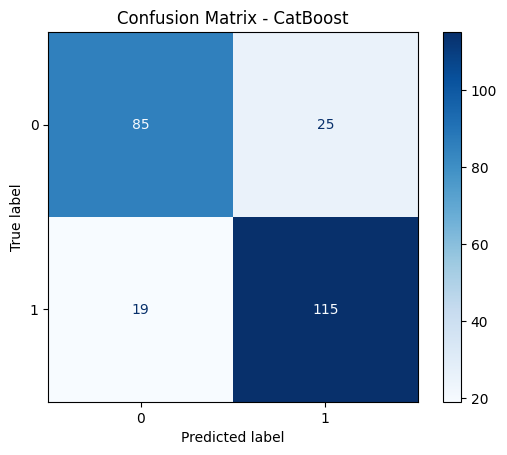

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - CatBoost")
plt.savefig("Confusion Matrix_CatBoost.png", dpi=300)
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_catboost_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                feature  importance
2       chest pain type   16.205472
10             ST slope   14.895108
4           cholesterol   11.303540
6           resting ecg   11.157354
9               oldpeak   10.044728
3          resting bp s    9.609949
0                   age    8.685726
7        max heart rate    8.249973
1                   sex    4.591058
8       exercise angina    3.104765
5   fasting blood sugar    2.152326


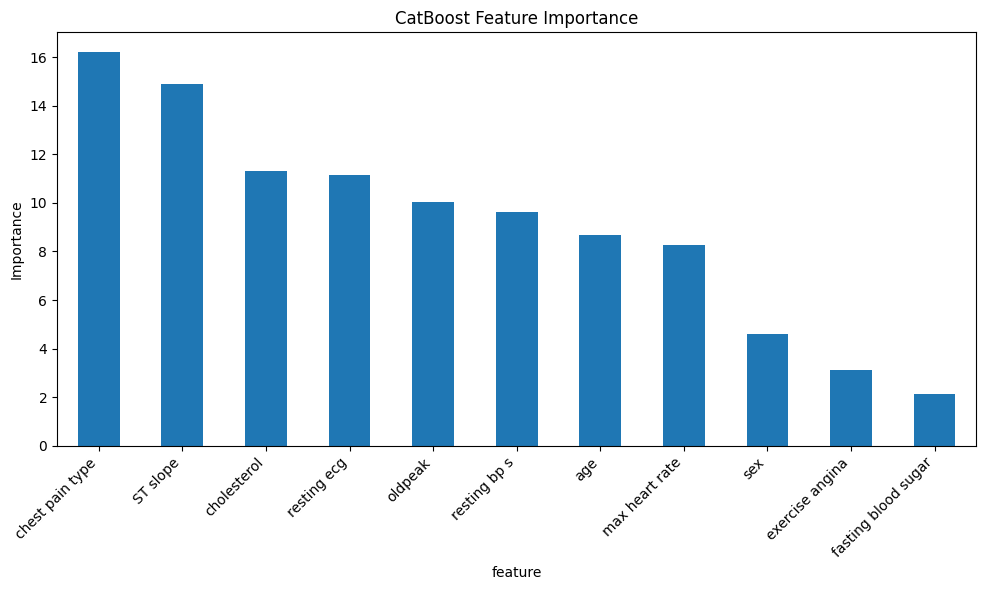

In [20]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("CatBoost Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Feature Importance_CatBoost.png", dpi=300)
plt.show()